# H6 magic-state distillation

Protocol: arXiv:2506.14688 ("Breaking even with magic", Quantinuum), §III "0-level distillation".
Native LightStim implementation: `lightstim/protocols/h6_distillation.py`.

The real protocol distills a pair of non-Clifford |H+⟩_L magic states, which Stim's stabilizer
formalism can't represent. Following the paper's own methodology for its scaling-law
simulations (Fig. 4), this substitutes a Clifford proxy state (reset → encode instead of the
true magic state) and studies how the **post-selected** logical error rate scales with the
physical two-qubit gate error rate `p`.

Two check variants (paper Fig. 1(e)/(f)) and two preparation paths are available:

- `variant="e"` (default): symmetric |H+,H+⟩_L check, both slots X-proxied.
- `variant="f"`: asymmetric |H+,Y-⟩_L check — the paper's actual Fig. 1(c) benchmarking pipeline.
  Slot 1's logical value is read out non-destructively via a dedicated Fig. 6 "Y2" flagged
  ancilla gadget before the final MX readout (mixing MX/MY into one destructive readout pass
  silently drops the code's own XA/XB closure detectors — see the module docstring).
- `prep="fig1d"` (default): unflagged, arbitrary-basis encoder (Fig. 1(d)); reaches fault
  distance 2 only together with the pre-check SE round + Bell-pair check.
- `prep="fig5"` (`variant="e"` only): flag-verified |00⟩_L encoder (Fig. 5) + transversal H —
  the paper's own route for its scaling-law simulations. Detects a fault during preparation
  itself, so a single SE round alone already reaches fault distance 2.

**Every detector in this circuit is tagged `post-select`** (H6 is a distance-2 code: it can only
detect, never correct, a fault — see the module docstring for why decoding instead of discarding
degrades the observed scaling from O(p²) to O(p)).

In [1]:
import sys
from pathlib import Path
import io, contextlib

ROOT = Path('../..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np

from lightstim.protocols.h6_distillation import (
    build_h6_distillation_circuit,
    inject_noise,
    run_simulation,
)
from lightstim.utils.fault_audit import low_weight_fault_audit

## 1. Build Circuit (variant "e", prep="fig1d")

{'num_qubits': 12, 'num_detectors': 8, 'num_observables': 2, 'rounds': 1, 'variant': 'e', 'prep': 'fig1d'}


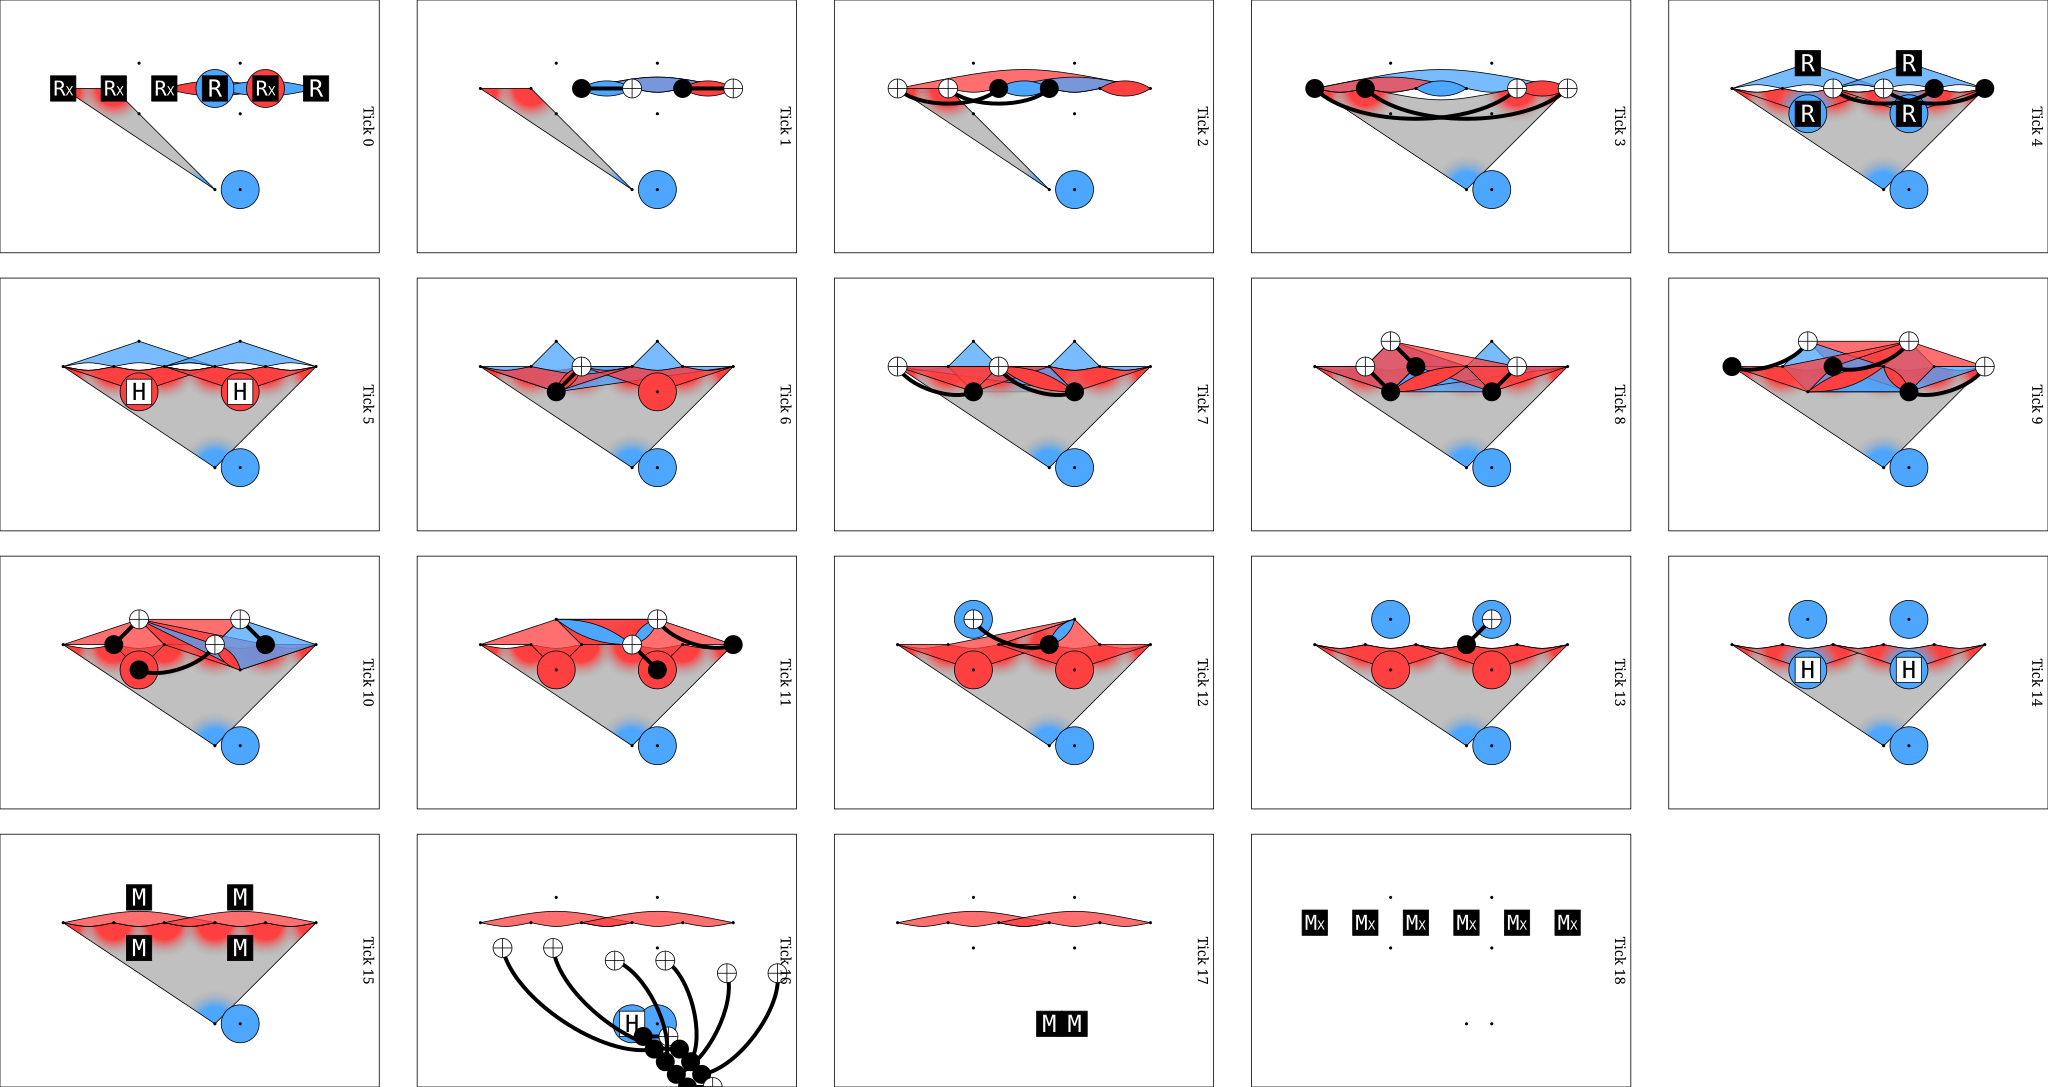

In [2]:
with contextlib.redirect_stdout(io.StringIO()):
    circuit, info, system = build_h6_distillation_circuit(rounds=1)
print(info)
circuit.without_noise().diagram("detslice-with-ops-svg")

## 2. Fault Distance

`rounds=1` (the default) should give circuit fault distance 2 — matching the paper's protocol and
the independently validated `H6-Distillation-DEQ` reference. `rounds=0` is shown for comparison:
it is NOT fault tolerant (distance 1), since LightStim's tracker has no prior round to anchor a
boundary detector to, so the code's own stabilizers never get checked.

In [3]:
for rounds in (0, 1):
    with contextlib.redirect_stdout(io.StringIO()):
        c, _, _ = build_h6_distillation_circuit(rounds=rounds)
    noisy = inject_noise(c, p=1e-3)
    print(f"rounds={rounds}: fault distance = {len(noisy.shortest_graphlike_error())}")

rounds=0: fault distance = 1
rounds=1: fault distance = 2


## 3. Variant "f" (asymmetric |H+,Y-⟩_L check)

Uses the same Bell-pair check as variant "e" (with a CY instead of CX coupling to slot 1), then a
separate Fig. 6 "Y2" flagged ancilla gadget to read out `Y_L1` non-destructively before the final,
uniform MX readout — see the module docstring for why that ordering matters. Only one observable
survives (`X_L0`): slot 1's logical value is consumed by the Y2 measurement itself, not carried
into `OBSERVABLE_INCLUDE`.

In [4]:
with contextlib.redirect_stdout(io.StringIO()):
    circuit_f, info_f, _ = build_h6_distillation_circuit(rounds=1, variant="f")
print(info_f)

for rounds in (1, 2):
    with contextlib.redirect_stdout(io.StringIO()):
        c, _, _ = build_h6_distillation_circuit(rounds=rounds, variant="f")
    noisy = inject_noise(c, p=1e-3)
    print(f"variant=f rounds={rounds}: fault distance = {len(noisy.shortest_graphlike_error())}")

{'num_qubits': 14, 'num_detectors': 10, 'num_observables': 1, 'rounds': 1, 'variant': 'f', 'prep': 'fig1d'}
variant=f rounds=1: fault distance = 2
variant=f rounds=2: fault distance = 2


## 4. Fig. 5 Flag-Verified Preparation (`prep="fig5"`)

`HSixLogicalOpSet.encode(..., flagged=True)` prepares `|00⟩_L` with two flag ancillas bracketing
the encoder's two control qubits, then a transversal Hadamard reaches `|++⟩_L` — the paper's own
route for its scaling-law simulations (variant "e" only for now). Compared to `prep="fig1d"`, this
adds 2 post-select detectors (the flag pair) and detects a fault during preparation itself, rather
than relying solely on the pre-check SE round + Bell-pair check to catch it after the fact.

In [5]:
with contextlib.redirect_stdout(io.StringIO()):
    circuit_fig5, info_fig5, _ = build_h6_distillation_circuit(rounds=1, prep="fig5")
print(info_fig5)

for rounds in (1, 2):
    with contextlib.redirect_stdout(io.StringIO()):
        c, _, _ = build_h6_distillation_circuit(rounds=rounds, prep="fig5")
    noisy = inject_noise(c, p=1e-3)
    print(f"prep=fig5 rounds={rounds}: fault distance = {len(noisy.shortest_graphlike_error())}")

{'num_qubits': 14, 'num_detectors': 10, 'num_observables': 2, 'rounds': 1, 'variant': 'e', 'prep': 'fig5'}
prep=fig5 rounds=1: fault distance = 2
prep=fig5 rounds=2: fault distance = 2


## 5. Fault Audit: `prep="fig1d"` vs `prep="fig5"`

Exact, non-statistical certification (`lightstim.utils.fault_audit`: every low-weight fault is
enumerated, not just the single worst-case witness `shortest_graphlike_error` finds) that both
preparation paths reach fault distance 2 — by different mechanisms: `fig1d` via the post-hoc SE
round + Bell-pair check, `fig5` via its own preparation-time flags.

In [6]:
for prep in ("fig1d", "fig5"):
    with contextlib.redirect_stdout(io.StringIO()):
        c, _, _ = build_h6_distillation_circuit(rounds=1, variant="e", prep=prep)
    result = low_weight_fault_audit(c)
    print(f"prep={prep}: {result.summary()}")

prep=fig1d: 564 fault probes (max weight 2) over 44 atomic locations: 474 detected, 90 undetected-harmless, undetected-logical: 0 -> circuit fault distance >= 2


prep=fig5: 630 fault probes (max weight 2) over 54 atomic locations: 528 detected, 102 undetected-harmless, undetected-logical: 0 -> circuit fault distance >= 2


## 6. Small p-sweep (variant "e", prep="fig1d")

Hardcoded, small-scale (matches `notebooks/README.md`'s convention: full sweeps belong in
`benchmarks/`, not here). Post-selection is automatic — `run_simulation` relies entirely on the
circuit's own `post-select` detector tags, no manual indices.

In [7]:
ps = np.array([0.002, 0.004, 0.008, 0.016])
accept_rates, lers = [], []
for p in ps:
    with contextlib.redirect_stdout(io.StringIO()):
        circuit, _, _ = build_h6_distillation_circuit(rounds=1)
    noisy = inject_noise(circuit, p=float(p))
    stats = run_simulation(noisy, max_shots=200_000, max_errors=200, num_workers=4)
    accept_rates.append(stats.post_selection_rate)
    lers.append(stats.logical_error_rate)
    print(f"p={p:.4f}  accept={stats.post_selection_rate:.4f}  ler={stats.logical_error_rate:.5f}")

slope, intercept = np.polyfit(np.log(ps), np.log(lers), 1)
print(f"\nfitted slope: {slope:.3f}  (paper predicts ~2.0)")

p=0.0020  accept=0.8966  ler=0.00005


p=0.0040  accept=0.8044  ler=0.00030


p=0.0080  accept=0.6489  ler=0.00126


p=0.0160  accept=0.4191  ler=0.00527

fitted slope: 2.219  (paper predicts ~2.0)


## 7. Plot

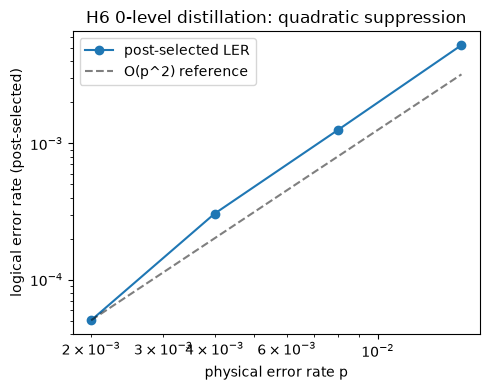

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))
ax.loglog(ps, lers, 'o-', label='post-selected LER')
ax.loglog(ps, (lers[0] / ps[0]**2) * ps**2, 'k--', alpha=0.5, label='O(p^2) reference')
ax.set_xlabel('physical error rate p')
ax.set_ylabel('logical error rate (post-selected)')
ax.legend()
ax.set_title('H6 0-level distillation: quadratic suppression')
fig.tight_layout()